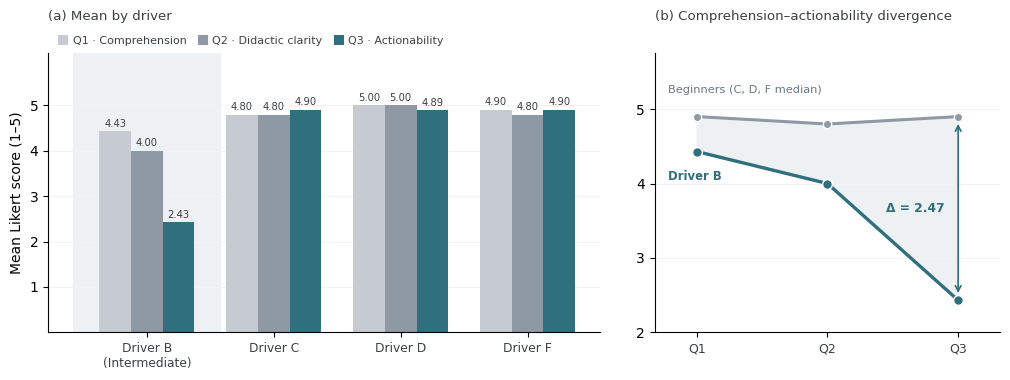

In [3]:
# ══════════════════════════════════════════════════════════════════════════
#  Figure — Post-feedback questionnaire results (Section 6.5)
#  Gestalt: proximity (per-driver clusters), similarity (slate = comprehension,
#  teal = actionability), figure-ground (shaded band isolating Driver B),
#  continuity (slope lines in panel b).
#  Responses from Thaís are excluded from this analysis.
# ══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,          # editable text in the final PDF
})

# ── Palette (neutral slate/teal, no alarm valence) ────────────────────────
C1, C2, C3 = '#C6CBD1', '#8E99A4', '#2F6F7E'   # Q1, Q2, Q3
BAND, TXT, MUT = '#EEF1F3', '#3C4043', '#6B7681'

# ── Data: pooled item means (all stints, both tracks) ─────────────────────
drivers = ['Driver B\n(Intermediate)', 'Driver C', 'Driver D', 'Driver F']
CG = [4.43, 4.80, 5.00, 4.90]   # Q1 — CG1, cognitive ease
DI = [4.00, 4.80, 5.00, 4.80]   # Q2 — DI1, didactic clarity
AC = [2.43, 4.90, 4.89, 4.90]   # Q3 — AC3, actionability

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(10.2, 3.9), gridspec_kw={'width_ratios': [1.6, 1]}
)

# ── Panel (a): grouped bars ───────────────────────────────────────────────
w, x = 0.25, np.arange(len(drivers))

ax1.axvspan(-0.58, 0.58, color=BAND, zorder=0)          # figure-ground
ax1.bar(x - w, CG, w, color=C1, zorder=2, label='Q1 · Comprehension')
ax1.bar(x,     DI, w, color=C2, zorder=2, label='Q2 · Didactic clarity')
ax1.bar(x + w, AC, w, color=C3, zorder=2, label='Q3 · Actionability')

for xi, (a, b, c) in enumerate(zip(CG, DI, AC)):
    for off, v in zip([-w, 0, w], [a, b, c]):
        ax1.text(xi + off, v + 0.10, f'{v:.2f}',
                 ha='center', fontsize=7.2, color=TXT)

ax1.set_xticks(x)
ax1.set_xticklabels(drivers, fontsize=8.8, color=TXT)
ax1.set_ylim(0, 6.15)
ax1.set_yticks([1, 2, 3, 4, 5])
ax1.set_ylabel("Mean Likert score (1\u20135)")   # antes: "(1-5)"
#ax1.set_ylabel('Mean Likert score (1–5)', fontsize=9.2, color=TXT)
ax1.yaxis.grid(True, color='#F1F3F4', lw=0.8)
ax1.set_axisbelow(True)

# Compact legend anchored left so no entry overflows the axes
ax1.legend(loc='upper left', bbox_to_anchor=(0.0, 1.1), ncol=3,
           frameon=False, fontsize=8.0, handlelength=0.9, handleheight=0.9,
           columnspacing=1.0, handletextpad=0.42, labelcolor=TXT)
ax1.set_title('(a) Mean by driver',
              fontsize=9.6, loc='left', pad=24, color=TXT)

# ── Panel (b): slope chart — continuity makes the gap legible ─────────────
xs = [0, 1, 2]
beg = [np.median([CG[1], CG[2], CG[3]]),
       np.median([DI[1], DI[2], DI[3]]),
       np.median([AC[1], AC[2], AC[3]])]
B = [CG[0], DI[0], AC[0]]
delta = beg[2] - B[2]

ax2.fill_between(xs, B, beg, color=BAND, zorder=0)
ax2.plot(xs, beg, '-o', color=C2, lw=2.2, ms=6, zorder=2, mec='white', mew=1)
ax2.plot(xs, B,   '-o', color=C3, lw=2.4, ms=7, zorder=3, mec='white', mew=1)

ax2.annotate('', xy=(2, beg[2] - 0.06), xytext=(2, B[2] + 0.06),
             arrowprops=dict(arrowstyle='<->', color=C3, lw=1.2))
ax2.text(1.9, (beg[2] + B[2]) / 2, f'Δ = {delta:.2f}',
         ha='right', va='center', fontsize=8.8, color=C3, fontweight='bold')
ax2.text(-0.22, 5.22, 'Beginners (C, D, F median)',
         fontsize=8.2, color=MUT)
ax2.text(-0.22, 4.05, 'Driver B', fontsize=8.4, color=C3, fontweight='bold')

ax2.set_xticks(xs)
ax2.set_xticklabels(['Q1', 'Q2', 'Q3'], fontsize=9, color=TXT)
ax2.set_xlim(-0.32, 2.32)
ax2.set_ylim(2, 5.75)
ax2.set_yticks([2, 3, 4, 5])
ax2.yaxis.grid(True, color='#F1F3F4', lw=0.8)
ax2.set_axisbelow(True)
ax2.set_title('(b) Comprehension–actionability divergence',
              fontsize=9.6, loc='left', pad=24, color=TXT)

plt.tight_layout(w_pad=2.6)
plt.savefig('fig_questionnaire_driverB.pdf', bbox_inches='tight')
plt.show()